In [3]:
import pandas as pd
import numpy as np
from math import pow
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier


In [2]:
df = pd.read_csv("atp_tennis_clean.csv")


My Attempt

In [9]:
df["y"] = (df["Winner"] == df["Player_1"]).astype(int)

X = df[["Surface", "Odd_1", "Odd_2", "Court"]]
X = X.dropna().reset_index(drop=True)
Y = df["y"]
Y = Y[X.index]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["Surface", "Court"]),
        ("num", "passthrough", ["Odd_1", "Odd_2"])
    ]
)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter = 1000))
])

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

print("Train accuracy:", model.score(X_train, y_train))
print("Test accuracy:", model.score(X_test, y_test))

Train accuracy: 0.5033448783033638
Test accuracy: 0.4953980453553468


CHATGPT Attempt

In [1]:
import pandas as pd
import numpy as np
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
from datetime import datetime
import json
import joblib

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

# ----------------------
# Config
# ----------------------

K_DEFAULT = 32.0
ELO_SCALE = 400.0
START_ELO = 500.0  # as requested

# ----------------------
# Utilities
# ----------------------
def find_col(df: pd.DataFrame, candidates: list[str]) -> Optional[str]:
    """Try to find a column matching any candidate name (case-insensitive, exact or contains)."""
    # exact
    for c in df.columns:
        lc = c.lower().strip()
        for cand in candidates:
            if lc == cand:
                return c
    # contains
    for cand in candidates:
        for c in df.columns:
            if cand in c.lower():
                return c
    return None

def expected_score(r_a: float, r_b: float, scale: float = ELO_SCALE) -> float:
    return 1.0 / (1.0 + 10.0 ** ((r_b - r_a) / scale))

@dataclass
class RatingEvent:
    date: Optional[pd.Timestamp]
    opponent: str
    result: str  # "W" or "L"
    delta: float
    new_elo: float
    meta: Tuple[str, str, str]  # (tournament, surface, round)

@dataclass
class Player:
    name: str
    elo: float = START_ELO
    wins: int = 0
    losses: int = 0
    history: List[RatingEvent] = field(default_factory=list)

# Global player db for Elo
players_db: Dict[str, Player] = {}

def ensure_player(name: str) -> Player:
    name = str(name).strip()
    if name not in players_db:
        players_db[name] = Player(name=name)
    return players_db[name]

def record_match_elo(
    p1: str, p2: str, winner: str,
    date=None, tournament="", surface="", rnd="",
    K: float = K_DEFAULT, scale: float = ELO_SCALE
) -> Tuple[float, float, float]:
    """Apply Elo update for a single match; return (pre_elo_p1, pre_elo_p2, elo_prob_p1)."""
    p1 = p1.strip(); p2 = p2.strip(); winner = winner.strip()
    a = ensure_player(p1); b = ensure_player(p2)
    Ea = expected_score(a.elo, b.elo, scale); Eb = 1.0 - Ea

    if winner == p1:
        Sa, Sb = 1.0, 0.0
    elif winner == p2:
        Sa, Sb = 0.0, 1.0
    else:
        raise ValueError("winner must equal p1 or p2")

    da = K * (Sa - Ea)
    db = K * (Sb - Eb)
    pre_a, pre_b = a.elo, b.elo

    a.elo += da
    b.elo += db

    if Sa == 1.0:
        a.wins += 1; b.losses += 1
        a.history.append(RatingEvent(date, b.name, "W", da, a.elo, (tournament, surface, rnd)))
        b.history.append(RatingEvent(date, a.name, "L", db, b.elo, (tournament, surface, rnd)))
    else:
        b.wins += 1; a.losses += 1
        b.history.append(RatingEvent(date, a.name, "W", db, b.elo, (tournament, surface, rnd)))
        a.history.append(RatingEvent(date, b.name, "L", da, a.elo, (tournament, surface, rnd)))

    return pre_a, pre_b, Ea

def top_n(n: int = 10):
    return sorted(players_db.values(), key=lambda p: p.elo, reverse=True)[:n]

# ----------------------
# Load & column mapping
# ----------------------
df = pd.read_csv("atp_tennis_clean.csv")

date_col    = find_col(df, ["date", "match_date"])
tourn_col   = find_col(df, ["tournament", "tourney_name", "tournament_name"])
surface_col = find_col(df, ["surface"])
round_col   = find_col(df, ["round", "rnd"])

# Prefer explicit "player_1"/"player_2" if present
p1_col = find_col(df, ["player_1", "player1", "p1"])
p2_col = find_col(df, ["player_2", "player2", "p2"])
winner_col = find_col(df, ["winner", "winner_name"])

# If your dataset is "winner_name"/"loser_name", you can swap these lines:
if p1_col is None and find_col(df, ["winner_name"]):
    p1_col = find_col(df, ["winner_name"])
if p2_col is None and find_col(df, ["loser_name"]):
    p2_col = find_col(df, ["loser_name"])
if winner_col is None:
    winner_col = find_col(df, ["winner", "winner_name"])

# Parse dates (fallback to synthetic order if absent)
if date_col is not None:
    df["_date"] = pd.to_datetime(df[date_col], errors="coerce")
else:
    df["_date"] = pd.to_datetime(np.arange(len(df)), unit="D", origin=pd.Timestamp("2000-01-01"))

# Basic string cleanup
for col in [tourn_col, surface_col, round_col, p1_col, p2_col, winner_col]:
    if col is not None and df[col].dtype == object:
        df[col] = df[col].astype(str).str.strip()

# ----------------------
# Build Elo + feature table
# ----------------------
rows = []
for _, row in df.sort_values(by="_date").iterrows():
    p1 = row[p1_col] if p1_col is not None else None
    p2 = row[p2_col] if p2_col is not None else None
    w  = row[winner_col] if winner_col is not None else None

    if not isinstance(p1, str) or not isinstance(p2, str) or not isinstance(w, str):
        continue
    p1 = p1.strip(); p2 = p2.strip(); w = w.strip()
    if p1 == "" or p2 == "":
        continue
    if w not in (p1, p2):
        # If winner is encoded as 1/2 (rare), try to infer; else skip
        if isinstance(row[winner_col], (int, float)) and not np.isnan(row[winner_col]):
            w = p1 if int(row[winner_col]) == 1 else p2
        else:
            continue

    pre1, pre2, elo_prob_p1 = record_match_elo(
        p1, p2, w,
        date=row["_date"],
        tournament=row[tourn_col] if tourn_col else "",
        surface=row[surface_col] if surface_col else "",
        rnd=row[round_col] if round_col else "",
        K=K_DEFAULT, scale=ELO_SCALE
    )

    rows.append({
        "date": row["_date"],
        "p1": p1,
        "p2": p2,
        "winner_is_p1": 1 if w == p1 else 0,
        "elo_p1_pre": pre1,
        "elo_p2_pre": pre2,
        "elo_diff": pre1 - pre2,
        "elo_prob_p1": elo_prob_p1,
        "surface": row[surface_col] if surface_col else "",
        "tournament": row[tourn_col] if tourn_col else "",
        "round": row[round_col] if round_col else "",
    })

feat_df = pd.DataFrame(rows).dropna(subset=["elo_diff"])

# ----------------------
# Train models
# ----------------------
X = feat_df[["elo_diff", "surface", "round"]].copy()
y = feat_df["winner_is_p1"].astype(int) 

numeric_features = ["elo_diff"]
categorical_features = ["surface", "round"]

preprocess = ColumnTransformer(
    transformers=[
        ("num", SkPipeline([
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, shuffle=True, random_state=42, stratify=y
)


# Small MultiLayer Perceptron Classifier (neural net)
mlp = Pipeline([
    ("prep", preprocess),
    ("clf", MLPClassifier(hidden_layer_sizes=(32, 16),
                          activation="relu",
                          max_iter=200 ,
                          random_state=42))
])
mlp.fit(X_tr, y_tr)
proba_mlp = mlp.predict_proba(X_te)[:, 1]
pred_mlp = (proba_mlp >= 0.5).astype(int)

# ----------------------
# Report metrics
# ----------------------
def metrics_block(y_true, y_proba, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "roc_auc": float(roc_auc_score(y_true, y_proba)),
        "log_loss": float(log_loss(y_true, y_proba)),
    }

print("MLP (Neural Net):   ", metrics_block(y_te, proba_mlp, pred_mlp))

MLP (Neural Net):    {'accuracy': 0.6536027953536689, 'roc_auc': 0.7192399648541136, 'log_loss': 0.6129673377051903}


c:\Anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(


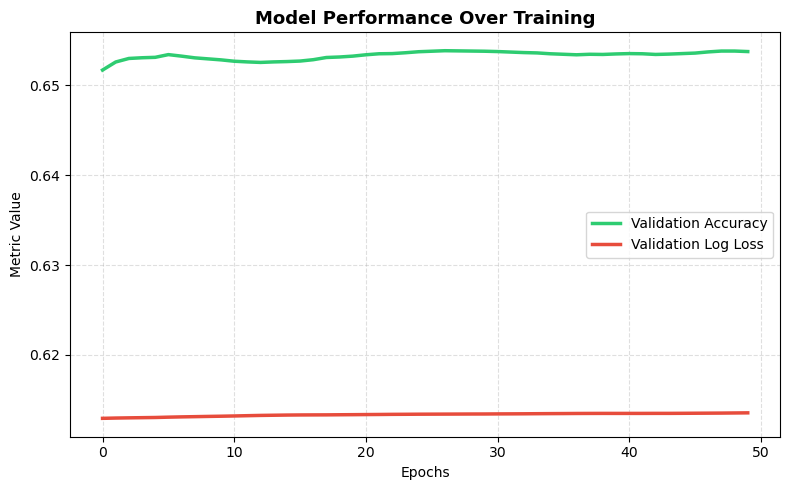

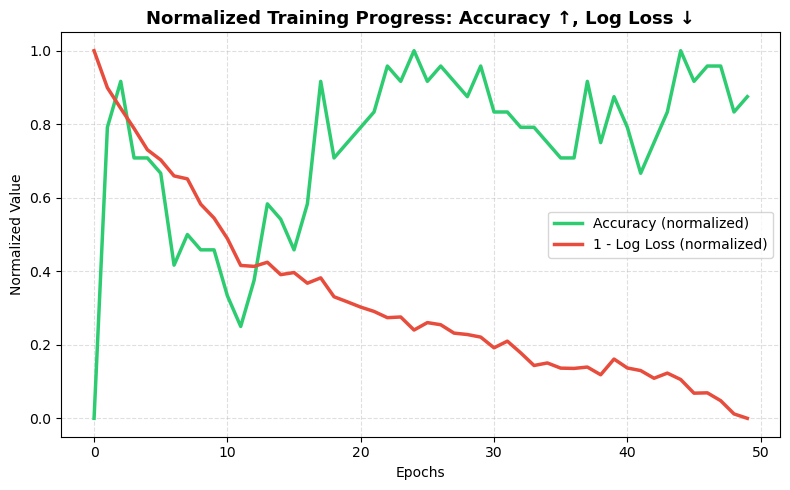

In [13]:
# ----- Epoch-by-epoch training on the same NN architecture -----
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, log_loss
import pandas as pd
import numpy as np

# 1) Fit the preprocessor once and transform splits
prep_fitted = preprocess.fit(X_tr)
Xtr = prep_fitted.transform(X_tr)
Xte = prep_fitted.transform(X_te)

# 2) Same NN as your pipeline, but train one epoch at a time
clf_epoch = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,   # same default as your pipeline
    alpha=0.0001,               # default L2
    max_iter=1,                 # one iteration per call
    warm_start=True,            # keep weights between calls
    random_state=42,
    shuffle=True
)

epochs = 50
val_acc, val_ll = [], []

for _ in range(epochs):
    clf_epoch.fit(Xtr, y_tr)                      # continues training
    yte_pred  = clf_epoch.predict(Xte)
    yte_proba = clf_epoch.predict_proba(Xte)[:, 1]
    val_acc.append(accuracy_score(y_te, yte_pred))
    val_ll.append(log_loss(y_te, yte_proba))

# 3) (Optional) light smoothing for readability
win = 5
val_acc_s = pd.Series(val_acc).rolling(win, min_periods=1).mean()
val_ll_s  = pd.Series(val_ll).rolling(win,  min_periods=1).mean()

# 4) Simple line chart: accuracy (green) and log loss (red)
plt.figure(figsize=(8,5))
plt.plot(val_acc_s, label="Validation Accuracy", linewidth=2.5, color="#2ecc71")
plt.plot(val_ll_s,  label="Validation Log Loss", linewidth=2.5, color="#e74c3c")
plt.title("Model Performance Over Training", fontsize=13, fontweight="bold")
plt.xlabel("Epochs")
plt.ylabel("Metric Value")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(loc="best", frameon=True, facecolor="white")
plt.tight_layout()
plt.show()

# ----- (Optional) normalized view so both trend upward together -----
acc_norm = (np.array(val_acc) - np.min(val_acc)) / (np.max(val_acc) - np.min(val_acc) + 1e-12)
ll_norm  = (np.array(val_ll)  - np.min(val_ll))  / (np.max(val_ll)  - np.min(val_ll)  + 1e-12)

plt.figure(figsize=(8,5))
plt.plot(acc_norm, label="Accuracy (normalized)", linewidth=2.5, color="#2ecc71")
plt.plot(1 - ll_norm, label="1 - Log Loss (normalized)", linewidth=2.5, color="#e74c3c")
plt.title("Normalized Training Progress: Accuracy ↑, Log Loss ↓", fontsize=13, fontweight="bold")
plt.xlabel("Epochs")
plt.ylabel("Normalized Value")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(loc="best", frameon=True, facecolor="white")
plt.tight_layout()
plt.show()
